<a href="https://colab.research.google.com/github/DSPL-B17/DSPL_hotelchainA/blob/main/logistic_regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Chain A – Booking Outcome Prediction
## Logistic Regression Model
Predicts: `checkout`, `canceled`, `no-show`

## 1. Imports & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Load datasets
from google.colab import drive
drive.mount('/content/drive')

val= pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/validation_cleaned.csv')
train= pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/train_cleaned.csv')
test= pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/test_cleaned.csv')

print('Train shape:', train.shape)
print('Validation shape:', val.shape)
print('Test shape:', test.shape)

Mounted at /content/drive
Train shape: (27499, 40)
Validation shape: (2749, 38)
Test shape: (4318, 36)


## 2. Feature Selection

In [3]:
# Target column
TARGET = 'reservation_status'

# Numerical features
num_features = [
    'age', 'adults', 'children', 'babies',
    'discount_rate', 'room_rate', 'Length_of_Stay',
    'Lead_Time', 'Checkin_Month', 'Checkin_DayOfWeek',
    'Is_Weekend_Checkin', 'Total_Guests', 'Is_Family',
    'income_enc', 'education_enc', 'Capacity_Exceeded'
]

# Categorical features to encode
cat_features = [
    'gender', 'hotel_type', 'meal_type', 'visted_previously',
    'previous_cancellations', 'deposit_type', 'booking_channel',
    'required_car_parking', 'use_promotion', 'Checkin_Season',
    'Guest_Type'
]

# Columns to drop (dates, IDs, revenue cols that leak the target, etc.)
drop_cols = [
    'expected_checkin', 'expected_checkout', 'booking_date',
    'ethnicity', 'country_region', 'age_group',
    'Gross_Revenue', 'Net_Revenue', 'Revenue_Loss',  # revenue leaks target
    'is_canceled'  # this is a derived binary of the target
]

print('Numerical features:', len(num_features))
print('Categorical features:', len(cat_features))

Numerical features: 16
Categorical features: 11


## 3. Preprocessing

In [4]:
def preprocess(df, cat_features, num_features, encoders=None, fit=False):
    df = df.copy()

    if encoders is None:
        encoders = {}

    # Encode categoricals
    for col in cat_features:
        if col not in df.columns:
            continue
        df[col] = df[col].astype(str).fillna('Unknown')
        if fit:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            encoders[col] = le
        else:
            le = encoders[col]
            # Handle unseen labels by mapping to -1
            known = set(le.classes_)
            df[col] = df[col].apply(lambda x: x if x in known else le.classes_[0])
            df[col] = le.transform(df[col])

    # Fill missing numericals with median from training
    for col in num_features:
        if col not in df.columns:
            continue
        if fit:
            encoders[f'{col}_median'] = df[col].median()
        df[col] = df[col].fillna(encoders[f'{col}_median'])

    all_features = [c for c in num_features + cat_features if c in df.columns]
    return df[all_features], encoders


# Encode target
label_map = {'checkout': 0, 'canceled': 1, 'no-show': 2}
reverse_map = {v: k for k, v in label_map.items()}

y_train = train[TARGET].map(label_map)
y_val   = val[TARGET].map(label_map)

# Preprocess features
X_train, encoders = preprocess(train, cat_features, num_features, fit=True)
X_val,   _        = preprocess(val,   cat_features, num_features, encoders=encoders, fit=False)
X_test,  _        = preprocess(test,  cat_features, num_features, encoders=encoders, fit=False)

print('X_train shape:', X_train.shape)
print('X_val shape:  ', X_val.shape)
print('X_test shape: ', X_test.shape)
print('\nClass distribution in train:')
print(y_train.map(reverse_map).value_counts())

X_train shape: (27499, 27)
X_val shape:   (2749, 27)
X_test shape:  (4318, 27)

Class distribution in train:
reservation_status
checkout    21240
canceled     4134
no-show      2125
Name: count, dtype: int64


## 4. Scale Features

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')

Scaling complete.


## 5. Train Logistic Regression & Tune with Validation Set
We try different values of `C` (regularisation strength) and pick the one with the best validation accuracy.

In [6]:
# Tune C using validation set
C_values = [0.01, 0.1, 1, 10, 100]
results = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',  # handles class imbalance
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val_scaled))
    results.append({'C': C, 'val_accuracy': val_acc})
    print(f'C={C:<6} -> Validation Accuracy: {val_acc:.4f}')

results_df = pd.DataFrame(results)
best_C = results_df.loc[results_df['val_accuracy'].idxmax(), 'C']
print(f'\nBest C: {best_C}')

C=0.01   -> Validation Accuracy: 0.4129
C=0.1    -> Validation Accuracy: 0.4125
C=1      -> Validation Accuracy: 0.4125
C=10     -> Validation Accuracy: 0.4125
C=100    -> Validation Accuracy: 0.4125

Best C: 0.01


## 6. Retrain on Train Data Using Best C

In [7]:
# Final model trained on training data with best C
final_model = LogisticRegression(
    C=best_C,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
final_model.fit(X_train_scaled, y_train)
print('Final model trained.')

Final model trained.


## 7. Evaluate on Validation Set

In [8]:
y_val_pred = final_model.predict(X_val_scaled)
y_val_prob = final_model.predict_proba(X_val_scaled)

print('=== Validation Set Results ===')
print(f'Accuracy: {accuracy_score(y_val, y_val_pred):.4f}')
print()
print(classification_report(
    y_val, y_val_pred,
    target_names=['checkout', 'canceled', 'no-show']
))

# ROC-AUC (one-vs-rest for multiclass)
roc_auc = roc_auc_score(y_val, y_val_prob, multi_class='ovr', average='weighted')
print(f'ROC-AUC (weighted OvR): {roc_auc:.4f}')

=== Validation Set Results ===
Accuracy: 0.4129

              precision    recall  f1-score   support

    checkout       0.60      0.56      0.58      1610
    canceled       0.27      0.16      0.20       741
     no-show       0.14      0.29      0.19       398

    accuracy                           0.41      2749
   macro avg       0.34      0.34      0.32      2749
weighted avg       0.44      0.41      0.42      2749

ROC-AUC (weighted OvR): 0.5211


## 8. Confusion Matrix

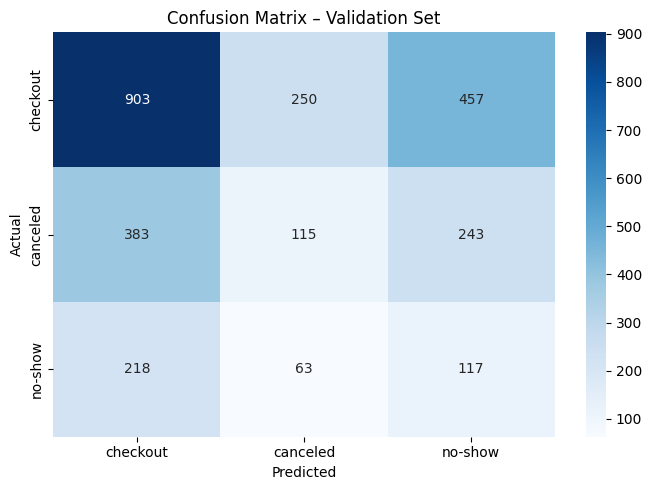

Saved: confusion_matrix.png


In [9]:
cm = confusion_matrix(y_val, y_val_pred)
class_names = ['checkout', 'canceled', 'no-show']

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix – Validation Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

## 9. Feature Importance (Coefficients)

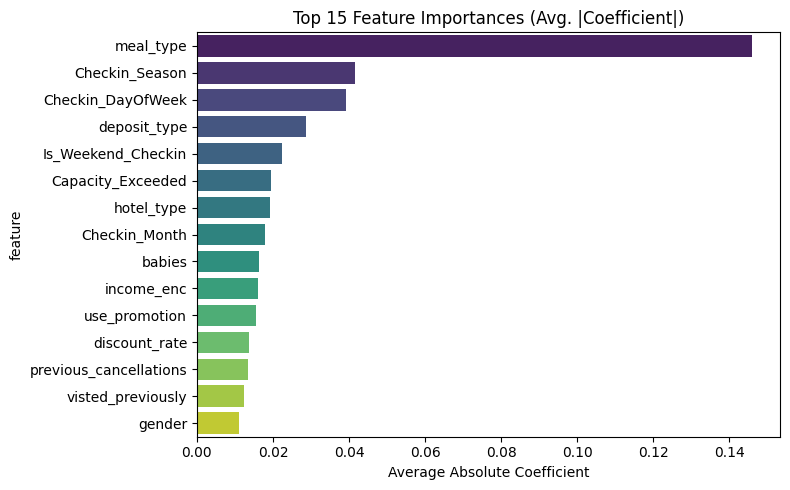

Saved: feature_importance.png


In [10]:
feature_names = X_train.columns.tolist()
classes = ['checkout', 'canceled', 'no-show']

# Average absolute coefficient across all classes
avg_coef = np.mean(np.abs(final_model.coef_), axis=0)
coef_df = pd.DataFrame({'feature': feature_names, 'importance': avg_coef})
coef_df = coef_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances (Avg. |Coefficient|)')
plt.xlabel('Average Absolute Coefficient')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Saved: feature_importance.png')

## 10. Predict on Test Set & Save Results

In [11]:
y_test_pred = final_model.predict(X_test_scaled)
y_test_prob = final_model.predict_proba(X_test_scaled)

# Map back to labels
y_test_labels = pd.Series(y_test_pred).map(reverse_map)

# Build results dataframe
test_results = test.copy()
test_results['predicted_status'] = y_test_labels.values
test_results['prob_checkout']    = y_test_prob[:, 0]
test_results['prob_canceled']    = y_test_prob[:, 1]
test_results['prob_no_show']     = y_test_prob[:, 2]

test_results.to_csv('test_predictions.csv', index=False)

print('=== Test Set Predictions ===')
print(y_test_labels.value_counts())
print('\nSaved: test_predictions.csv')

=== Test Set Predictions ===
no-show     1559
canceled    1417
checkout    1342
Name: count, dtype: int64

Saved: test_predictions.csv


## 11. Summary

In [12]:
print('==================== MODEL SUMMARY ====================')
print(f'Model          : Logistic Regression (Multinomial)')
print(f'Best C         : {best_C}')
print(f'Solver         : lbfgs')
print(f'Class Weights  : balanced')
print(f'Validation Acc : {accuracy_score(y_val, y_val_pred):.4f}')
print(f'ROC-AUC (OvR)  : {roc_auc:.4f}')
print(f'Features Used  : {X_train.shape[1]}')
print(f'Train Samples  : {X_train.shape[0]}')
print(f'Test Samples   : {X_test.shape[0]}')
print('=======================================================')

==================== MODEL SUMMARY ====================
Model          : Logistic Regression (Multinomial)
Best C         : 0.01
Solver         : lbfgs
Class Weights  : balanced
Validation Acc : 0.4129
ROC-AUC (OvR)  : 0.5211
Features Used  : 27
Train Samples  : 27499
Test Samples   : 4318


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

acc = accuracy_score(y_val, y_val_pred)
roc = roc_auc_score(y_val, y_val_prob, multi_class='ovr', average='weighted')

print(f'Accuracy : {acc*100:.2f}%')
print(f'ROC AUC  : {roc*100:.2f}%')
print()
print(classification_report(
    y_val, y_val_pred,
    target_names=['checkout', 'canceled', 'no-show']
))


Accuracy : 41.29%
ROC AUC  : 52.11%

              precision    recall  f1-score   support

    checkout       0.60      0.56      0.58      1610
    canceled       0.27      0.16      0.20       741
     no-show       0.14      0.29      0.19       398

    accuracy                           0.41      2749
   macro avg       0.34      0.34      0.32      2749
weighted avg       0.44      0.41      0.42      2749

